# Tarea 2 — Vectorización y análisis de sentimiento

**Procesamiento y Clasificación de Datos · MCD, FCFM-UANL**

## Qué se hace

Dos cosas, conectadas:

1. **Vectorizar** las reseñas —convertir texto en números— y estudiar las propiedades de los
   vectores que salen: dimensión, dispersión, y qué miden sus distancias.
2. **Análisis de sentimiento** con un léxico de polaridad, comparando el puntaje del texto contra
   la calificación en estrellas que el propio autor puso.

La segunda parte es un experimento con respuesta verificable: si el sentimiento del texto no sube
con las estrellas, algo está mal. Las estrellas son la verdad del autor; el texto es lo que vamos
a medir.

## Datos

Los mismos de la Tarea 1: `data/resenas_muestra.csv` (84,750 reseñas de Amazon en dos categorías,
estratificadas por estrella). Preparados en `comun/descargar_datos.ipynb`.

## 0. Verificar librerías

In [1]:
import importlib.util

REQUERIDAS = ["pandas", "numpy", "matplotlib", "sklearn", "afinn"]
PIP = {"sklearn": "scikit-learn"}

faltan = [PIP.get(p, p) for p in REQUERIDAS if importlib.util.find_spec(p) is None]

if faltan:
    print("Instalando:", ", ".join(faltan))
    %pip install -q {" ".join(faltan)}
    print("\n>>> REINICIA el kernel (Restart) y corre de nuevo desde arriba <<<")
else:
    print("Todas las librerías están instaladas ✓")

Instalando: afinn
Note: you may need to restart the kernel to use updated packages.

>>> REINICIA el kernel (Restart) y corre de nuevo desde arriba <<<


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from afinn import Afinn

FIG = Path("figuras"); FIG.mkdir(exist_ok=True)
CATS = ["musica", "belleza"]
COLOR = {"musica": "#2a6f97", "belleza": "#c1442e"}
SEMILLA = 42

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150,
                     "savefig.bbox": "tight", "font.size": 10})

datos = pd.read_csv("../data/resenas_muestra.csv")
datos["text"] = datos["text"].astype(str)
print(f"{len(datos):,} reseñas")

84,750 reseñas


---
# Parte 1 — Vectorización

## 1.1 La idea

Un modelo no puede leer. Para que un algoritmo trabaje con texto hay que convertir cada reseña en
un vector de números. La receta más simple es la **bolsa de palabras**: una columna por cada
palabra del vocabulario, y en cada celda, cuántas veces aparece esa palabra en esa reseña.

Se pierde el orden ("no me gustó" y "me no gustó" dan el mismo vector), pero se gana algo enorme:
las reseñas se vuelven puntos en un espacio, y entre puntos hay **distancias**. Medir qué tan
parecidas son dos reseñas se vuelve geometría.

Aquí se prueban las dos variantes vistas en clase:

- **CountVectorizer** — conteo crudo de cada palabra
- **TF-IDF** — el conteo, pero castigado si la palabra aparece en todos lados. Una palabra que
  está en todas las reseñas (como "product") no distingue nada; TF-IDF le baja el peso.

In [3]:
# min_df=5: ignorar palabras que aparecen en menos de 5 reseñas
cv = CountVectorizer(min_df=5, stop_words="english")
X_count = cv.fit_transform(datos["text"])

tfidf = TfidfVectorizer(min_df=5, stop_words="english")
X_tfidf = tfidf.fit_transform(datos["text"])

print(f"Matriz: {X_count.shape[0]:,} reseñas x {X_count.shape[1]:,} palabras")

Matriz: 84,750 reseñas x 21,029 palabras


## 1.2 Propiedades de la matriz

La matriz tiene decenas de miles de columnas. ¿Cómo cabe en memoria? Porque casi toda es ceros:
una reseña de 40 palabras solo enciende ~40 columnas de las decenas de miles disponibles. A eso
se le llama **dispersión** (*sparsity*), y es la propiedad central de estos vectores.

In [4]:
celdas = X_count.shape[0] * X_count.shape[1]
no_ceros = X_count.nnz
dispersion = 1 - no_ceros / celdas

print(f"Celdas totales   : {celdas:,}")
print(f"Celdas con valor : {no_ceros:,}")
print(f"Dispersión       : {dispersion:.4%} de ceros")
print()
palabras_por_resena = np.asarray((X_count > 0).sum(axis=1)).ravel()
print(f"Palabras distintas por reseña: media {palabras_por_resena.mean():.1f}, "
      f"mediana {np.median(palabras_por_resena):.0f}")

Celdas totales   : 1,782,207,750
Celdas con valor : 1,764,424
Dispersión       : 99.9010% de ceros

Palabras distintas por reseña: media 20.8, mediana 11


**Lectura.** Más del 99.9% de la matriz es ceros. Por eso scikit-learn usa matrices dispersas
(solo guarda las celdas con valor); si se guardara completa, no cabría en la memoria de la laptop.

## 1.3 El efecto de `min_df`

`min_df` descarta palabras que aparecen en menos de N reseñas. Es el hiperparámetro que controla
el tamaño del vocabulario, y conviene ver qué tan drástico es su efecto.

min_df=  1  ->   81,301 palabras
min_df=  2  ->   39,511 palabras
min_df=  5  ->   21,029 palabras
min_df= 10  ->   13,583 palabras
min_df= 25  ->    7,497 palabras
min_df= 50  ->    4,704 palabras
min_df=100  ->    2,782 palabras


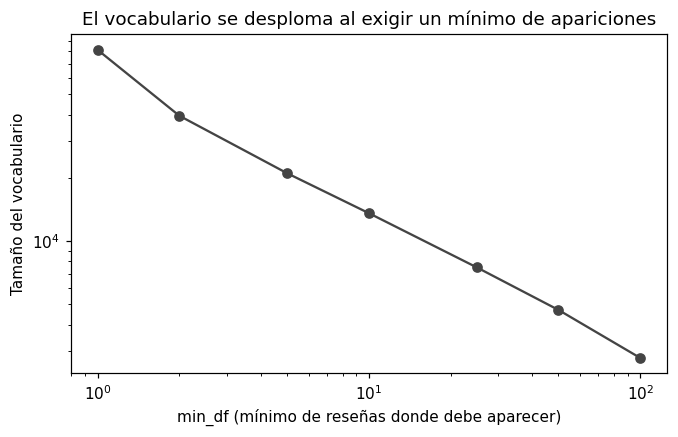

In [5]:
valores = [1, 2, 5, 10, 25, 50, 100]
tamanos = []
for v in valores:
    n = len(CountVectorizer(min_df=v, stop_words="english")
            .fit(datos["text"]).vocabulary_)
    tamanos.append(n)
    print(f"min_df={v:>3}  ->  {n:>7,} palabras")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(valores, tamanos, "o-", color="#444")
ax.set_xlabel("min_df (mínimo de reseñas donde debe aparecer)")
ax.set_ylabel("Tamaño del vocabulario")
ax.set_title("El vocabulario se desploma al exigir un mínimo de apariciones")
ax.set_xscale("log"); ax.set_yscale("log")
plt.savefig(FIG / "1_min_df.png")
plt.show()

**Lectura.** Pasar de `min_df=1` a `min_df=5` tira más de la mitad del vocabulario. Esas
palabras que aparecen en 1–4 reseñas son typos, nombres propios y rarezas: columnas que ocupan
espacio y no generalizan. La ley de Zipf en acción — la mayoría de las palabras son rarísimas.

## 1.4 ¿Qué miden las distancias entre vectores?

La prueba de fuego de una representación: ¿los vectores cercanos corresponden a textos parecidos?

Se mide con **similitud coseno** (el ángulo entre dos vectores, 0 = nada que ver, 1 = idénticos),
comparando tres grupos de pares de reseñas:

- pares **dentro de música**
- pares **dentro de belleza**
- pares **cruzados** (una de cada)

Si la representación captura contenido, los pares cruzados deben parecerse menos. Se usa una
muestra de 800 reseñas por categoría porque comparar todas contra todas serían 3,600 millones de
pares.

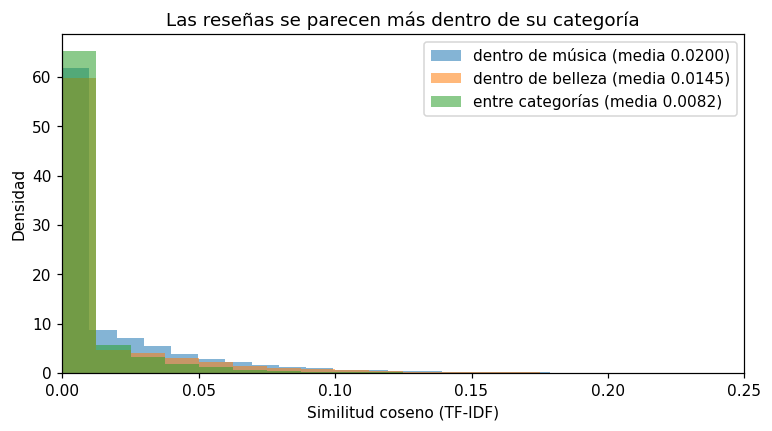

dentro de música     media = 0.0200
dentro de belleza    media = 0.0145
entre categorías     media = 0.0082


In [6]:
rng = np.random.default_rng(SEMILLA)
idx = {cat: rng.choice(np.where(datos["categoria"] == cat)[0], 800, replace=False)
       for cat in CATS}

S = cosine_similarity(X_tfidf[np.concatenate([idx["musica"], idx["belleza"]])])
n = 800
tri = np.triu_indices(n, k=1)

sim = {
    "dentro de música": S[:n, :n][tri],
    "dentro de belleza": S[n:, n:][tri],
    "entre categorías": S[:n, n:].ravel(),
}

fig, ax = plt.subplots(figsize=(8, 4))
for nombre, v in sim.items():
    ax.hist(v, bins=80, alpha=0.55, density=True, label=f"{nombre} (media {v.mean():.4f})")
ax.set_xlim(0, 0.25)
ax.set_xlabel("Similitud coseno (TF-IDF)")
ax.set_ylabel("Densidad")
ax.set_title("Las reseñas se parecen más dentro de su categoría")
ax.legend()
plt.savefig(FIG / "2_similitud.png")
plt.show()

for nombre, v in sim.items():
    print(f"{nombre:<20} media = {v.mean():.4f}")

**Lectura.** Las similitudes son bajas en general (vectores dispersos casi no comparten
palabras), pero el orden es el correcto: los pares dentro de una categoría se parecen más que los
cruzados. La geometría del espacio refleja el contenido — que es exactamente lo que un clasificador
va a explotar en la Tarea 3.

## 1.5 Count vs TF-IDF: qué palabra pesa más

La diferencia práctica entre las dos representaciones se ve preguntando: ¿cuáles son las palabras
con mayor peso total en cada una?

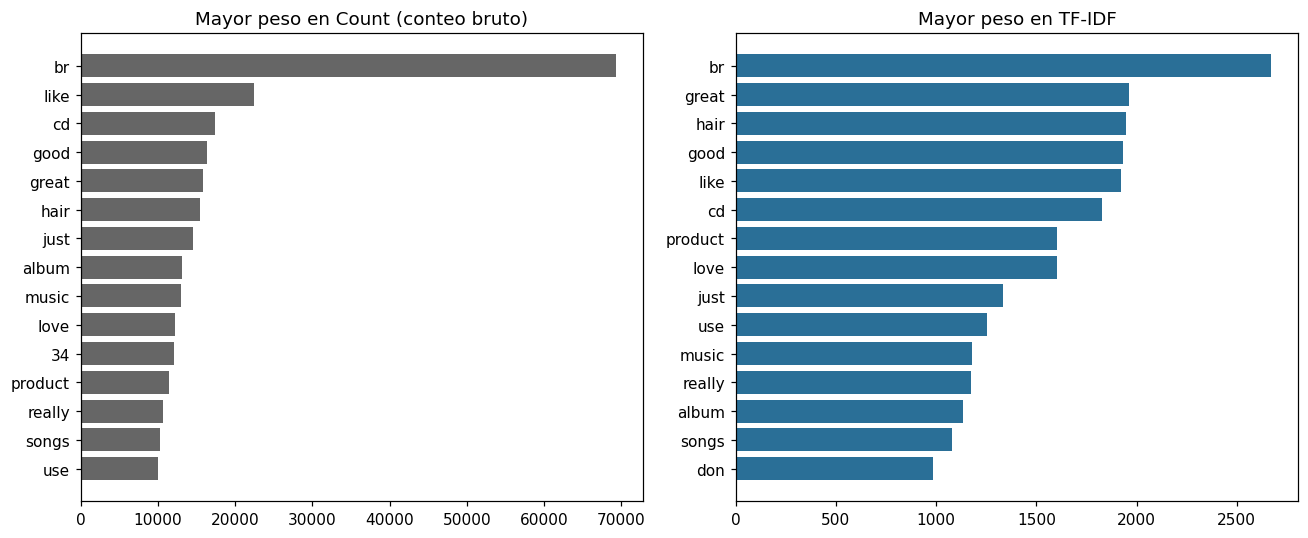

In [7]:
vocab = np.array(cv.get_feature_names_out())
top_count = pd.Series(np.asarray(X_count.sum(axis=0)).ravel(), index=vocab).nlargest(15)

vocab_t = np.array(tfidf.get_feature_names_out())
top_tfidf = pd.Series(np.asarray(X_tfidf.sum(axis=0)).ravel(), index=vocab_t).nlargest(15)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(top_count.index[::-1], top_count.values[::-1], color="#666")
axes[0].set_title("Mayor peso en Count (conteo bruto)")
axes[1].barh(top_tfidf.index[::-1], top_tfidf.values[::-1], color="#2a6f97")
axes[1].set_title("Mayor peso en TF-IDF")
plt.tight_layout()
plt.savefig(FIG / "3_count_vs_tfidf.png")
plt.show()

**Lectura.** Las listas se parecen pero no son iguales: TF-IDF baja el peso de palabras
transversales y sube términos más específicos. Con `stop_words="english"` ya se quitó lo peor;
el reordenamiento que queda es el "IDF" haciendo su trabajo.

---
# Parte 2 — Análisis de sentimiento

## 2.1 El método: léxico AFINN

Como en clase: un **diccionario de polaridad**. AFINN es una lista de ~2,500 palabras en inglés,
cada una con un puntaje de −5 (muy negativa) a +5 (muy positiva), asignado a mano por Finn Nielsen.
El sentimiento de una reseña es la suma de los puntajes de sus palabras.

Es deliberadamente simple: no entiende negaciones ("not good" suma como "good"), ni sarcasmo, ni
contexto. Eso lo hace transparente — cada puntaje se puede auditar palabra por palabra — y sus
errores son predecibles. La pregunta del experimento es si esa simpleza alcanza para recuperar la
calificación que el autor puso.

In [8]:
afinn = Afinn()

# esto tarda ~1 minuto: 85 mil reseñas
datos["sentimiento"] = datos["text"].apply(afinn.score)

# normalizar por longitud: una reseña larga acumula más puntos solo por ser larga
datos["palabras"] = datos["text"].str.split().str.len()
datos["sent_norm"] = datos["sentimiento"] / datos["palabras"]

datos[["sentimiento", "sent_norm"]].describe().round(3)

,sentimiento,sent_norm
count,84750.000,84750.000
mean,4.394,0.135
std,8.233,0.254
min,-78.000,-2.000
25%,0.000,0.000
50%,3.000,0.083
75%,6.000,0.206
max,415.000,3.000


La normalización importa por lo que vimos en la Tarea 1: las reseñas de música son el doble
de largas. Sin normalizar, música parecería "más intensa" solo por escribir más. `sent_norm` es
puntos de sentimiento **por palabra**.

## 2.2 El experimento: ¿el texto coincide con las estrellas?

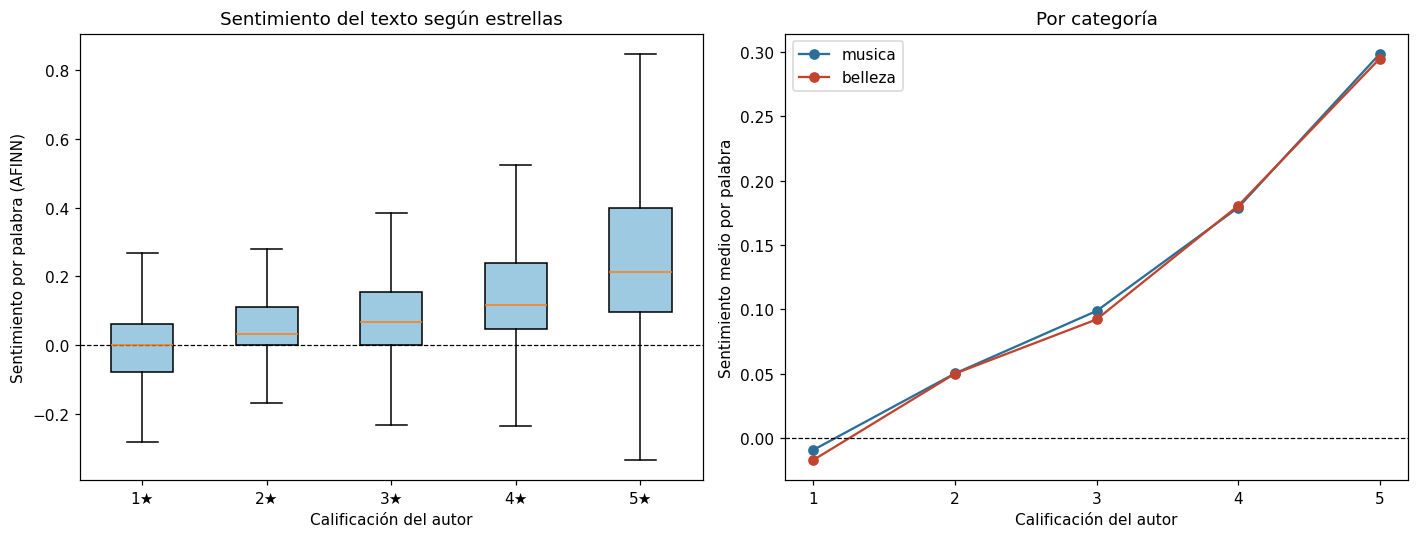

rating          1       2       3       4       5
categoria                                        
belleza   -0.0171  0.0500  0.0921  0.1805  0.2948
musica    -0.0093  0.0501  0.0987  0.1790  0.2985


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

orden = [1.0, 2.0, 3.0, 4.0, 5.0]
grupos = [datos.loc[datos["rating"] == r, "sent_norm"] for r in orden]

bp = axes[0].boxplot(grupos, showfliers=False, patch_artist=True)
axes[0].set_xticklabels([f"{int(r)}★" for r in orden])
for caja in bp["boxes"]:
    caja.set_facecolor("#9ecae1")
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[0].set_xlabel("Calificación del autor")
axes[0].set_ylabel("Sentimiento por palabra (AFINN)")
axes[0].set_title("Sentimiento del texto según estrellas")

medias = datos.groupby(["categoria", "rating"])["sent_norm"].mean().unstack()
for cat in CATS:
    axes[1].plot(orden, medias.loc[cat], "o-", label=cat, color=COLOR[cat])
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set_xlabel("Calificación del autor")
axes[1].set_ylabel("Sentimiento medio por palabra")
axes[1].set_title("Por categoría")
axes[1].set_xticks(orden)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG / "4_sentimiento_estrellas.png")
plt.show()

print(medias.round(4))

In [10]:
from scipy.stats import spearmanr

rho, _ = spearmanr(datos["rating"], datos["sent_norm"])
print(f"Correlación de Spearman (rating vs sentimiento): {rho:.3f}")

# correlacion por categoria
for cat in CATS:
    g = datos[datos["categoria"] == cat]
    r, _ = spearmanr(g["rating"], g["sent_norm"])
    print(f"  {cat}: {r:.3f}")

Correlación de Spearman (rating vs sentimiento): 0.499
  musica: 0.489
  belleza: 0.492


Se usa Spearman (correlación de rangos) porque las estrellas son ordinales: 4★ es más que
3★, pero la distancia entre 4 y 5 no tiene por qué ser igual a la de 1 a 2.

## 2.3 ¿Dónde falla el léxico?

Un promedio que sube no cuenta toda la historia. Los errores interesantes son los extremos:
reseñas de 1★ con sentimiento muy positivo, y de 5★ con sentimiento muy negativo.

In [11]:
err_pos = datos[(datos["rating"] == 1) & (datos["sent_norm"] > 0.15)]
err_neg = datos[(datos["rating"] == 5) & (datos["sent_norm"] < -0.10)]

print(f"1★ con texto 'positivo': {len(err_pos):,} reseñas")
print(f"5★ con texto 'negativo': {len(err_neg):,} reseñas\n")

print("=== Ejemplos de 1★ que AFINN lee como positivas ===")
for t in err_pos["text"].sample(3, random_state=1):
    print(" *", t[:160].replace("\n", " "), "\n")

print("=== Ejemplos de 5★ que AFINN lee como negativas ===")
for t in err_neg["text"].sample(3, random_state=1):
    print(" *", t[:160].replace("\n", " "), "\n")

1★ con texto 'positivo': 1,679 reseñas
5★ con texto 'negativo': 218 reseñas

=== Ejemplos de 1★ que AFINN lee como positivas ===
 * Only had one song that was any good. the other songs were song not of the original sons. 

 * Cute just not for me, I returned it the quality was great 

 * Did not work at all like advertised. 

=== Ejemplos de 5★ que AFINN lee como negativas ===
 * Max factor never disappoints!!! 

 * I love it  even tho i dont like blue eyeshadow dont have nothing bad to say 

 * Easy to use, no mess. 



Al leer los ejemplos aparecen los sospechosos de siempre: **negaciones** ("not worth the
praise"), **sarcasmo**, comparaciones ("expected better"), y reseñas de 5★ que describen contenido
triste (una canción sobre una pérdida) sin que la reseña sea negativa. Son los límites conocidos
de cualquier método de diccionario.

## 2.4 Conexión de las dos partes

La vectorización y el sentimiento no son temas separados: el léxico AFINN es, en el fondo, un
**producto punto** entre el vector de conteos de la reseña y un vector fijo de polaridades. Es
decir: el sentimiento por diccionario es una proyección lineal en el espacio vectorial de la
Parte 1. La Tarea 3 va a *aprender* esos pesos de los datos en lugar de heredarlos de un
diccionario — y la comparación entre ambos enfoques queda planteada.

---
## 3. Generar el reporte

Escribe `README.md` con los resultados insertados, igual que en la Tarea 1. GitHub lo muestra
automáticamente al abrir la carpeta `Tarea2/`.

In [12]:
def f(x, d=0):
    return f"{x:,.{d}f}"


reporte = f"""# Tarea 2 — Vectorización y análisis de sentimiento

**Procesamiento y Clasificación de Datos · MCD, FCFM-UANL**

## Objetivo

Convertir las reseñas en vectores, estudiar las propiedades de esa representación, y medir el
sentimiento del texto con un léxico de polaridad comparándolo contra la calificación en estrellas
del propio autor.

## Datos

Los de la Tarea 1: {f(len(datos))} reseñas de Amazon (categorías `Digital_Music` y `All_Beauty`),
muestreadas de forma estratificada por estrella. Preparación en `comun/descargar_datos.ipynb`.

## Metodología

**Vectorización.** Bolsa de palabras con `CountVectorizer` y `TfidfVectorizer`
(`min_df=5`, stopwords en inglés). Se estudian dimensión, dispersión, efecto de `min_df` y
estructura de distancias (similitud coseno).

**Sentimiento.** Léxico AFINN: cada palabra tiene polaridad de −5 a +5; el puntaje de una reseña
es la suma. Se normaliza por número de palabras, porque las reseñas de música son el doble de
largas (Tarea 1) y acumularían puntos solo por extensión. La comparación contra estrellas usa
correlación de Spearman, apropiada para una escala ordinal.

## Resultados

### Propiedades de los vectores

| Propiedad | Valor |
|---|---:|
| Reseñas (filas) | {f(X_count.shape[0])} |
| Vocabulario (columnas, min_df=5) | {f(X_count.shape[1])} |
| Dispersión | {dispersion:.3%} de ceros |
| Palabras distintas por reseña (mediana) | {f(np.median(palabras_por_resena))} |

La matriz es dispersa en extremo: cada reseña enciende ~{f(np.median(palabras_por_resena))}
columnas de las {f(X_count.shape[1])} disponibles. Por eso estas matrices se almacenan en formato
disperso.

![Efecto de min_df](figuras/1_min_df.png)

El vocabulario se desploma al exigir apariciones mínimas: la mayoría de las palabras son rarísimas
(typos, nombres propios). `min_df=5` reduce el vocabulario a menos de la mitad sin perder
información útil.

### Las distancias miden contenido

![Similitud coseno](figuras/2_similitud.png)

| Pares | Similitud media |
|---|---:|
| Dentro de música | {sim['dentro de música'].mean():.4f} |
| Dentro de belleza | {sim['dentro de belleza'].mean():.4f} |
| Entre categorías | {sim['entre categorías'].mean():.4f} |

Las reseñas se parecen más a las de su propia categoría que a las de la otra. La geometría del
espacio vectorial captura el contenido — condición necesaria para que la clasificación de la
Tarea 3 funcione.

![Count vs TF-IDF](figuras/3_count_vs_tfidf.png)

### Sentimiento contra estrellas

![Sentimiento vs estrellas](figuras/4_sentimiento_estrellas.png)

El sentimiento del texto **sube monótonamente con las estrellas** en ambas categorías.
Correlación de Spearman global: **ρ = {rho:.3f}**.

La mediana de 1★–2★ queda en territorio negativo y la de 4★–5★ en positivo. Un diccionario de
2,500 palabras, sin entender gramática, recupera la señal esencial de la calificación.

### Dónde falla el léxico

- **{f(len(err_pos))}** reseñas de 1★ con sentimiento por palabra > 0.15
- **{f(len(err_neg))}** reseñas de 5★ con sentimiento por palabra < −0.10

Al inspeccionarlas aparecen los límites conocidos del método: negaciones ("not good" suma como
"good"), sarcasmo, comparaciones ("expected better"), y reseñas positivas de contenido triste
(una canción sobre una pérdida). Son errores estructurales de cualquier método de diccionario:
AFINN ve palabras, no oraciones.

## Conclusiones

1. La representación bolsa-de-palabras produce vectores de decenas de miles de dimensiones con
   >99.9% de ceros; `min_df` es la palanca que controla ese tamaño.
2. Las distancias en ese espacio no son ruido: separan categorías de contenido sin que nadie les
   enseñara a hacerlo.
3. Un léxico simple recupera la relación texto–calificación (ρ = {rho:.3f}), con fallas
   predecibles en negación y sarcasmo.
4. El sentimiento por diccionario equivale a un producto punto con pesos fijos; la clasificación
   supervisada (Tarea 3) aprenderá esos pesos de los datos, y cabe esperar que supere al
   diccionario precisamente en los casos donde este falla.

## Limitaciones

- AFINN es para inglés y no maneja negaciones, sarcasmo ni contexto.
- La normalización por palabra atenúa, pero no elimina, el efecto de la longitud.
- La muestra estratificada no refleja la distribución real de estrellas de Amazon (deliberado).

## Reproducir

1. `comun/descargar_datos.ipynb` (una vez)
2. `Tarea2/vectorizacion_sentimiento.ipynb`

Requiere `pandas`, `numpy`, `matplotlib`, `scikit-learn`, `afinn`, `scipy`.

## Referencias

- Nielsen, F. Å. (2011). *A new ANEW: evaluation of a word list for sentiment analysis in
  microblogs*. arXiv:1103.2903.
- Hou, Y. et al. (2024). *Bridging Language and Items for Retrieval and Recommendation*.
  arXiv:2403.03952.
"""

Path("README.md").write_text(reporte, encoding="utf-8")
print("README.md escrito ✓")


README.md escrito ✓
